In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from black_scholes import call_price, put_price
from greeks import all_greeks, delta
from monte_carlo import monte_carlo_price, convergence_mc
from delta_hedging import delta_hedging, simuler_prix

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("✓ Tous les modules chargés !")

✓ Tous les modules chargés !


In [2]:
# ── Paramètres ───────────────────────────────────────────
S0, K, T, r, sigma = 100, 100, 1.0, 0.05, 0.20

C = call_price(S0, K, T, r, sigma)
P = put_price(S0, K, T, r, sigma)

print(f"{'Paramètre':<20} {'Valeur'}")
print("-" * 30)
print(f"{'Sous-jacent S':<20} {S0} €")
print(f"{'Strike K':<20} {K} €")
print(f"{'Maturité T':<20} {T} an")
print(f"{'Taux r':<20} {r*100:.1f} %")
print(f"{'Volatilité σ':<20} {sigma*100:.1f} %")
print("-" * 30)
print(f"{'Prix CALL':<20} {C:.4f} €")
print(f"{'Prix PUT':<20} {P:.4f} €")

Paramètre            Valeur
------------------------------
Sous-jacent S        100 €
Strike K             100 €
Maturité T           1.0 an
Taux r               5.0 %
Volatilité σ         20.0 %
------------------------------
Prix CALL            10.4506 €
Prix PUT             5.5735 €


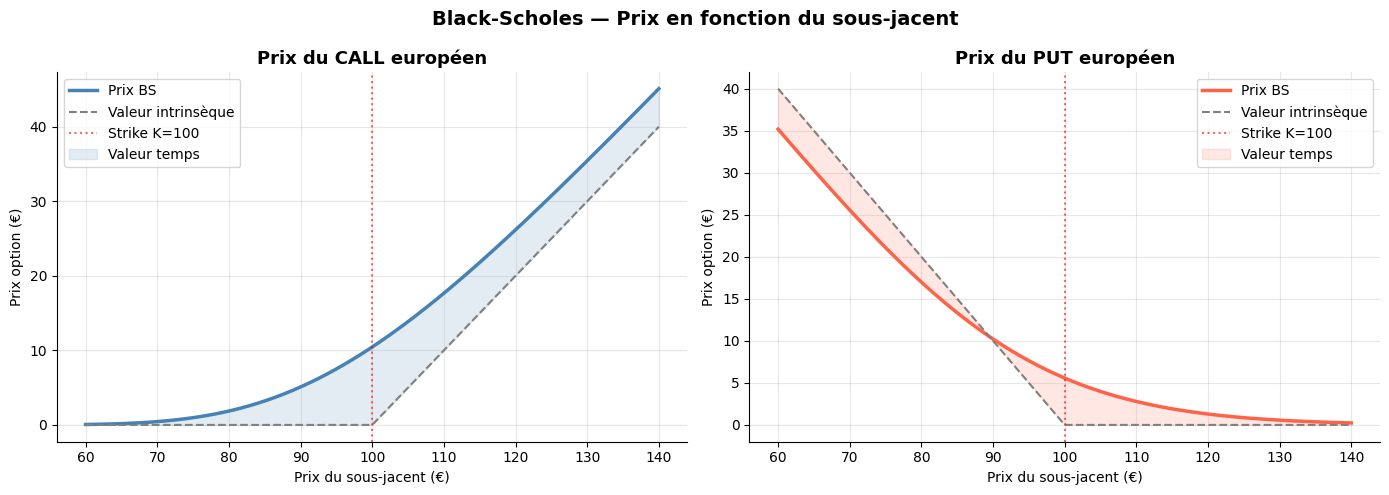

✓ Graphique sauvegardé dans report/


In [3]:
# ── Prix call/put en fonction du sous-jacent ─────────────
spots = np.linspace(60, 140, 200)
calls = [call_price(S, K, T, r, sigma) for S in spots]
puts  = [put_price(S, K, T, r, sigma)  for S in spots]
intrinsic_call = np.maximum(spots - K, 0)
intrinsic_put  = np.maximum(K - spots, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(spots, calls, color='steelblue', linewidth=2.5, label='Prix BS')
axes[0].plot(spots, intrinsic_call, '--', color='gray', linewidth=1.5, label='Valeur intrinsèque')
axes[0].axvline(K, color='red', linestyle=':', alpha=0.6, label=f'Strike K={K}')
axes[0].fill_between(spots, intrinsic_call, calls, alpha=0.15, color='steelblue', label='Valeur temps')
axes[0].set_title('Prix du CALL européen', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Prix du sous-jacent (€)')
axes[0].set_ylabel('Prix option (€)')
axes[0].legend()

axes[1].plot(spots, puts, color='tomato', linewidth=2.5, label='Prix BS')
axes[1].plot(spots, intrinsic_put, '--', color='gray', linewidth=1.5, label='Valeur intrinsèque')
axes[1].axvline(K, color='red', linestyle=':', alpha=0.6, label=f'Strike K={K}')
axes[1].fill_between(spots, intrinsic_put, puts, alpha=0.15, color='tomato', label='Valeur temps')
axes[1].set_title('Prix du PUT européen', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Prix du sous-jacent (€)')
axes[1].set_ylabel('Prix option (€)')
axes[1].legend()

plt.suptitle('Black-Scholes — Prix en fonction du sous-jacent', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/prix_options.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique sauvegardé dans report/")

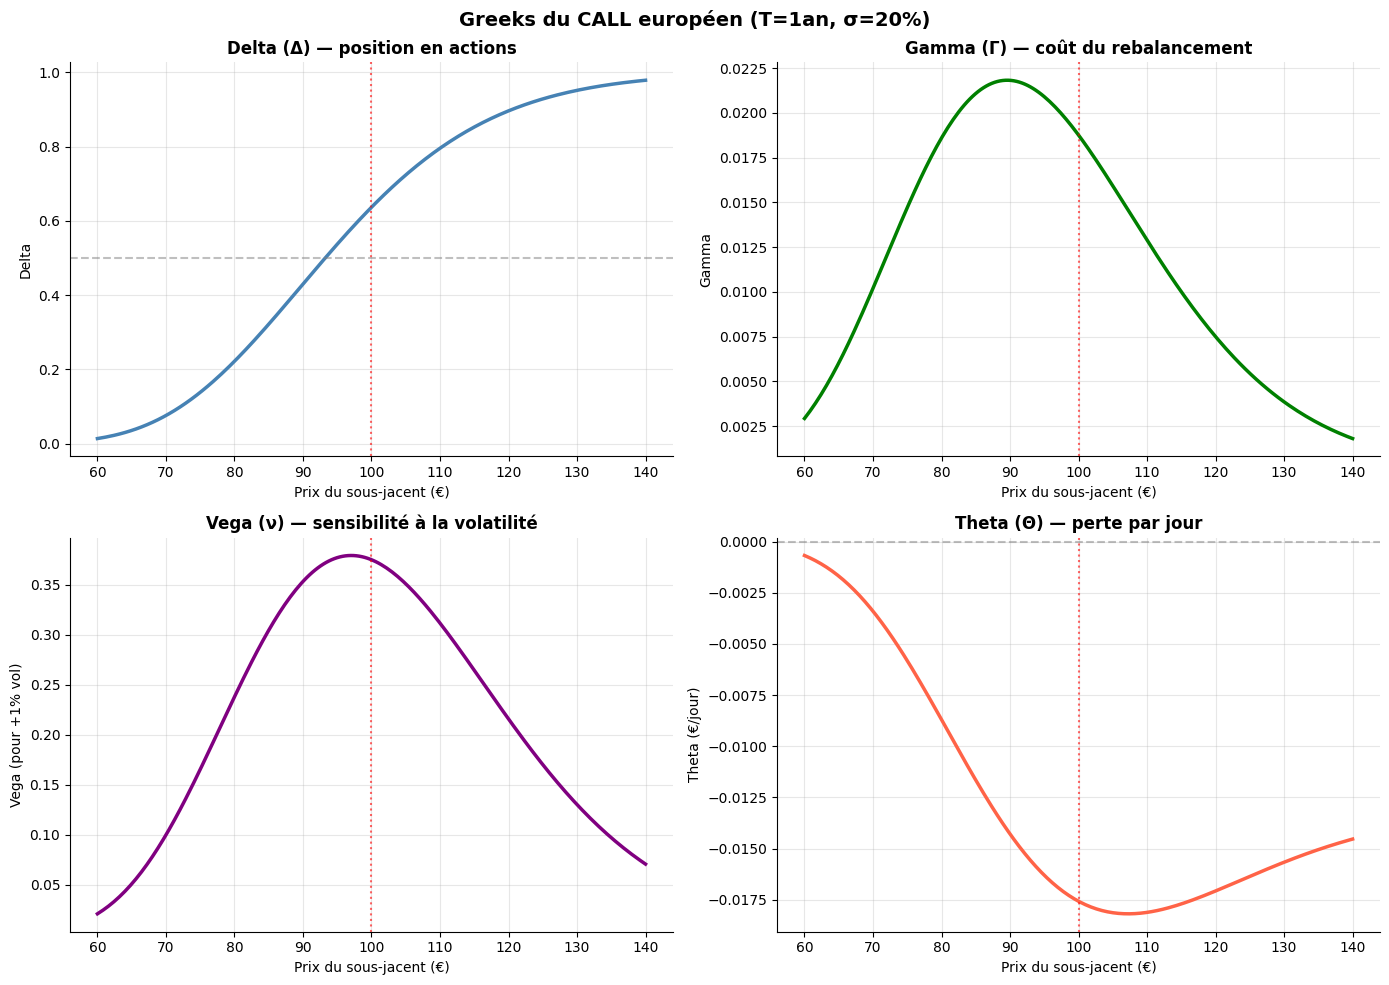

✓ Graphique Greeks sauvegardé !


In [4]:
# ── Greeks du call en fonction du sous-jacent ────────────
spots = np.linspace(60, 140, 200)

deltas = [delta(S, K, T, r, sigma, "call") for S in spots]
gammas = [all_greeks(S, K, T, r, sigma)["gamma"] for S in spots]
vegas  = [all_greeks(S, K, T, r, sigma)["vega"]  for S in spots]
thetas = [all_greeks(S, K, T, r, sigma)["theta"] for S in spots]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(spots, deltas, color='steelblue', linewidth=2.5)
axes[0,0].axvline(K, color='red', linestyle=':', alpha=0.6)
axes[0,0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0,0].set_title('Delta (Δ) — position en actions', fontweight='bold')
axes[0,0].set_ylabel('Delta')

axes[0,1].plot(spots, gammas, color='green', linewidth=2.5)
axes[0,1].axvline(K, color='red', linestyle=':', alpha=0.6)
axes[0,1].set_title('Gamma (Γ) — coût du rebalancement', fontweight='bold')
axes[0,1].set_ylabel('Gamma')

axes[1,0].plot(spots, vegas, color='purple', linewidth=2.5)
axes[1,0].axvline(K, color='red', linestyle=':', alpha=0.6)
axes[1,0].set_title('Vega (ν) — sensibilité à la volatilité', fontweight='bold')
axes[1,0].set_ylabel('Vega (pour +1% vol)')

axes[1,1].plot(spots, thetas, color='tomato', linewidth=2.5)
axes[1,1].axvline(K, color='red', linestyle=':', alpha=0.6)
axes[1,1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1,1].set_title('Theta (Θ) — perte par jour', fontweight='bold')
axes[1,1].set_ylabel('Theta (€/jour)')

for ax in axes.flatten():
    ax.set_xlabel('Prix du sous-jacent (€)')

plt.suptitle('Greeks du CALL européen (T=1an, σ=20%)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/greeks.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique Greeks sauvegardé !")

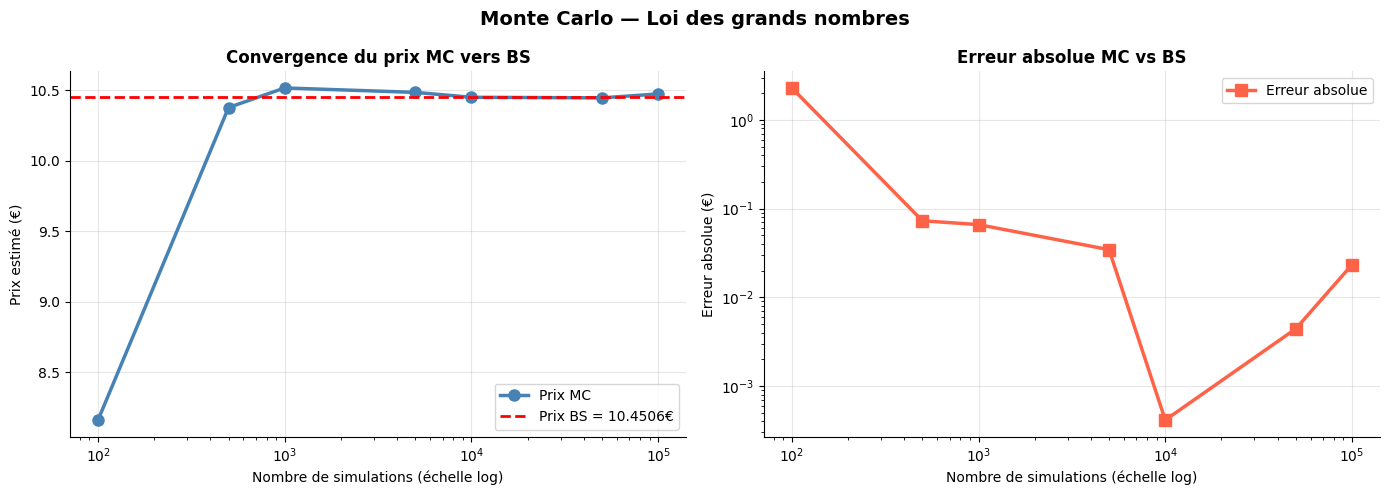

✓ Graphique Monte Carlo sauvegardé !


In [5]:
# ── Convergence MC vers BS ────────────────────────────────
resultats = convergence_mc(S0, K, T, r, sigma, "call")
ns     = [r["n_simulations"] for r in resultats]
prix   = [r["prix_MC"]       for r in resultats]
erreurs= [r["erreur_abs"]    for r in resultats]
bs_ref = resultats[0]["prix_BS"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogx(ns, prix, 'o-', color='steelblue', linewidth=2.5, markersize=8, label='Prix MC')
axes[0].axhline(bs_ref, color='red', linestyle='--', linewidth=2, label=f'Prix BS = {bs_ref:.4f}€')
axes[0].set_title('Convergence du prix MC vers BS', fontweight='bold')
axes[0].set_xlabel('Nombre de simulations (échelle log)')
axes[0].set_ylabel('Prix estimé (€)')
axes[0].legend()

axes[1].loglog(ns, erreurs, 's-', color='tomato', linewidth=2.5, markersize=8, label='Erreur absolue')
axes[1].set_title('Erreur absolue MC vs BS', fontweight='bold')
axes[1].set_xlabel('Nombre de simulations (échelle log)')
axes[1].set_ylabel('Erreur absolue (€)')
axes[1].legend()

plt.suptitle('Monte Carlo — Loi des grands nombres', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/convergence_mc.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Graphique Monte Carlo sauvegardé !")

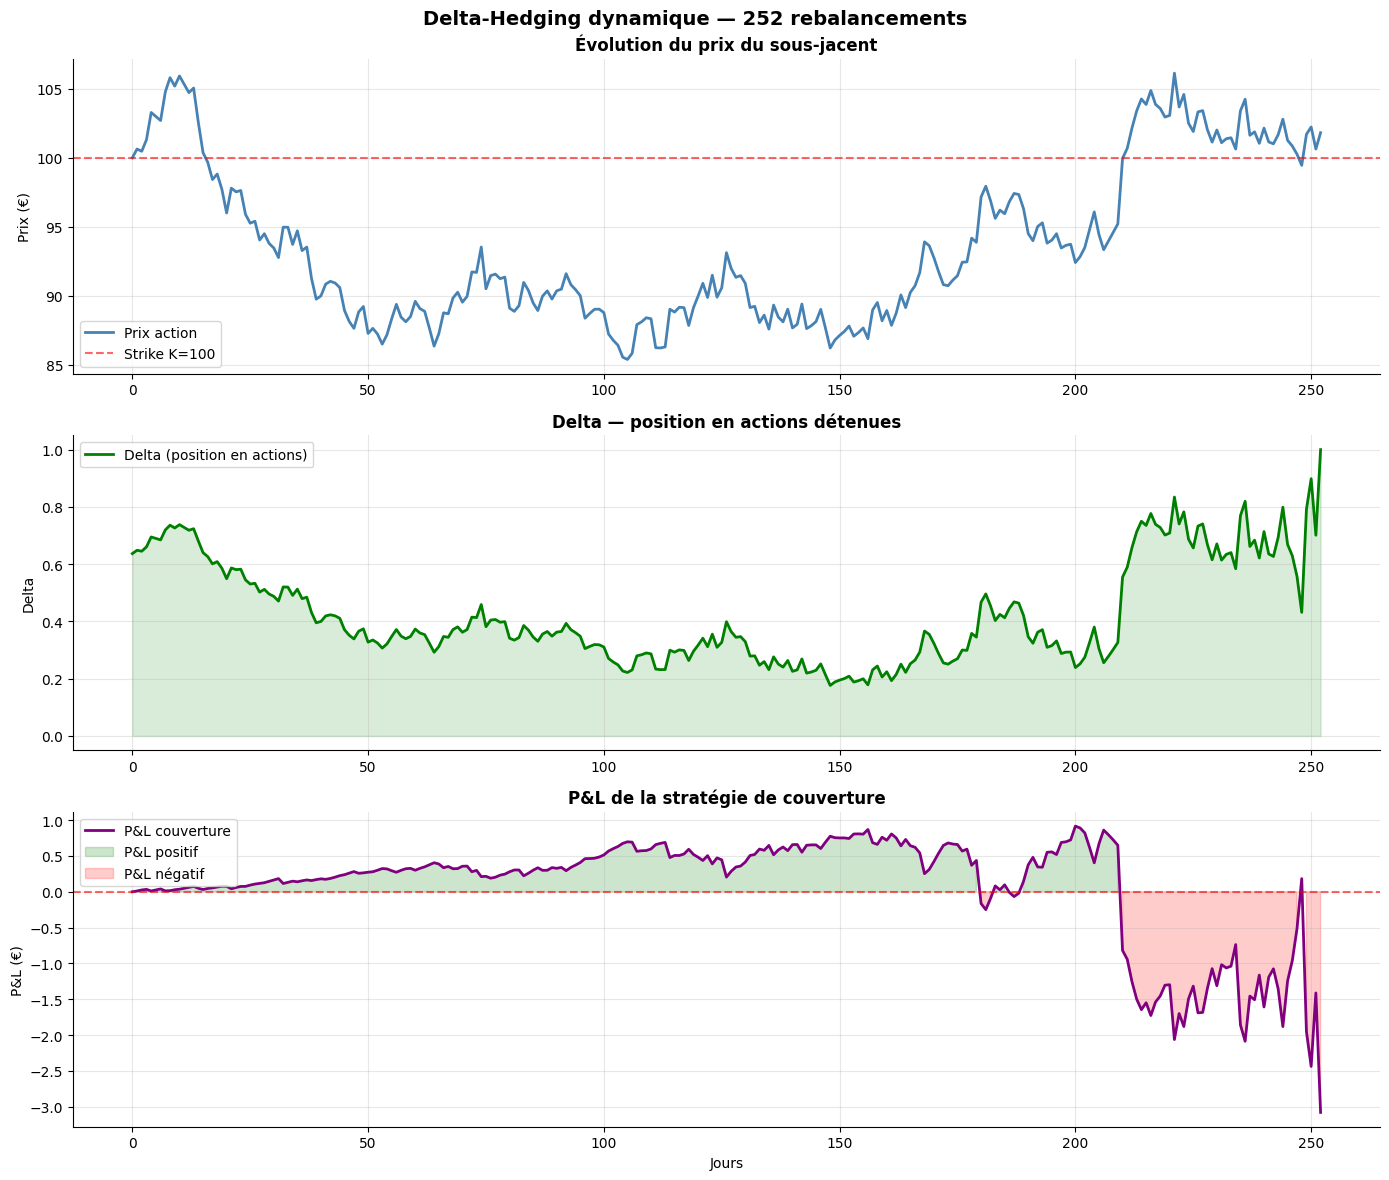


  Résumé de la simulation :
  Prime reçue         : 10.4506 €
  Prix final action   : 101.8211 €
  P&L final           : -3.0789 €
  Erreur moy. absolue : 0.5679 €  (5.4% de la prime)
✓ Simulation sauvegardée !


In [6]:
# ── Simulation delta-hedging ─────────────────────────────
df = delta_hedging(S0, K, T, r, sigma, n_steps=252)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Graphique 1 : évolution du prix
axes[0].plot(df["step"], df["prix_action"], color='steelblue', linewidth=2, label='Prix action')
axes[0].axhline(K, color='red', linestyle='--', alpha=0.6, label=f'Strike K={K}')
axes[0].set_title('Évolution du prix du sous-jacent', fontweight='bold')
axes[0].set_ylabel('Prix (€)')
axes[0].legend()

# Graphique 2 : delta et position
axes[1].plot(df["step"], df["delta"], color='green', linewidth=2, label='Delta (position en actions)')
axes[1].fill_between(df["step"], 0, df["delta"], alpha=0.15, color='green')
axes[1].set_title('Delta — position en actions détenues', fontweight='bold')
axes[1].set_ylabel('Delta')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend()

# Graphique 3 : P&L
axes[2].plot(df["step"], df["pnl"], color='purple', linewidth=2, label='P&L couverture')
axes[2].axhline(0, color='red', linestyle='--', alpha=0.6)
axes[2].fill_between(df["step"], 0, df["pnl"],
                     where=[p >= 0 for p in df["pnl"]], alpha=0.2, color='green', label='P&L positif')
axes[2].fill_between(df["step"], 0, df["pnl"],
                     where=[p < 0 for p in df["pnl"]], alpha=0.2, color='red', label='P&L négatif')
axes[2].set_title('P&L de la stratégie de couverture', fontweight='bold')
axes[2].set_ylabel('P&L (€)')
axes[2].set_xlabel('Jours')
axes[2].legend()

plt.suptitle('Delta-Hedging dynamique — 252 rebalancements', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/delta_hedging.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Résumé de la simulation :")
print(f"  Prime reçue         : {call_price(S0, K, T, r, sigma):.4f} €")
print(f"  Prix final action   : {df['prix_action'].iloc[-1]:.4f} €")
print(f"  P&L final           : {df['pnl'].iloc[-1]:.4f} €")
print(f"  Erreur moy. absolue : {df['pnl'].abs().mean():.4f} €  ({df['pnl'].abs().mean()/call_price(S0,K,T,r,sigma)*100:.1f}% de la prime)")
print("✓ Simulation sauvegardée !")